<div style="border:2px solid #2196F3; border-radius:12px; padding:20px; background-color:#E3F2FD; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#0D47A1;">⚡ Project Introduction & Strategic Objectives</h2>
  <p style="color:#1565C0;">
    In the transition towards sustainable transportation, the integration of Electric Vehicles (EVs) into the power grid presents both opportunities and challenges. 
    This notebook explores a sophisticated dataset containing thousands of charging sessions, station metrics, and environmental variables.
  </p>

  <h3 style="color:#1976D2;">🎯 Objectives:</h3>
  <ul style="line-height:1.8; color:#0D47A1;">
    <li>🔌 <strong>Identify Charging Patterns:</strong> Understand when and where EVs are charging.</li>
    <li>⚡ <strong>Grid Load Management:</strong> Analyze the relationship between individual charging sessions and total station load.</li>
    <li>📈 <strong>Optimization Evaluation:</strong> Assess how factors like renewable energy ratios and dynamic pricing affect the 'Optimization Reward'.</li>
    <li>🌱 <strong>Sustainability Insights:</strong> Evaluate the role of weather and traffic in energy demand.</li>
  </ul>
</div>

<div style="border:2px solid #FF9800; border-radius:12px; padding:20px; background-color:#FFF3E0; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#F57C00;">🛠️ Environment Setup & Data Acquisition</h2>
  <p style="color:#EF6C00; line-height:1.6;">
    In this section, we prepare our analytical environment by importing essential libraries for data manipulation, visualization, and statistical analysis.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#00BFA5; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🐼 pandas</span>
    <span style="background-color:#1976D2; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📊 matplotlib</span>
    <span style="background-color:#4CAF50; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📈 seaborn</span>
    <span style="background-color:#FF5722; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔢 numpy</span>
  </div>

In [1]:
# ==============================================================================
# SECTION 2: ENVIRONMENT SETUP & DATA ACQUISITION
# ==============================================================================

# Standard library imports for data processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Set global aesthetics for the notebook
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Define a function to load the dataset with a health check
def load_and_verify_data(file_path):
    """
    Loads the dataset and performs an initial validation check.
    Returns the dataframe and a summary string.
    """
    try:
        data = pd.read_csv("/kaggle/input/datasets/mjawad17/ev-charging-and-grid-optimization-data/charging_ev_and_grid_optimization_dataset.csv")
        rows, cols = data.shape
        print(f"✅ Dataset loaded successfully.")
        print(f"📊 Total Records: {rows}")
        print(f"📐 Total Features: {cols}")
        return data
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

# Load the provided CSV dataset
file_name = 'charging_ev_and_grid_optimization_dataset.csv'
df = load_and_verify_data(file_name)

# Display the first few records to visualize the structure
print("\n--- Initial Data Preview ---")
print(df.head(10))

# Examine the schema and memory footprint
print("\n--- Dataset Schema Info ---")
df.info()

# Detailed memory usage per column
print("\n--- Memory Usage (bytes) ---")
print(df.memory_usage(deep=True))

# Check for any immediate obvious data entry issues
print("\n--- Null Value Audit ---")
print(df.isnull().sum())

✅ Dataset loaded successfully.
📊 Total Records: 8354
📐 Total Features: 27

--- Initial Data Preview ---
       timestamp station_id location_type vehicle_id vehicle_type  \
0  1/1/2025 0:00      ST004         Urban    EV10000  Two-Wheeler   
1  1/1/2025 0:15      ST005         Urban    EV10001  Two-Wheeler   
2  1/1/2025 0:30      ST019       Highway    EV10002          Car   
3  1/1/2025 0:45      ST008         Urban    EV10003  Two-Wheeler   
4  1/1/2025 1:00      ST008       Highway    EV10004  Two-Wheeler   
5  1/1/2025 1:15      ST014       Highway    EV10005          Bus   
6  1/1/2025 1:30      ST004         Urban    EV10006          Bus   
7  1/1/2025 1:45      ST020       Highway    EV10007          Car   
8  1/1/2025 2:00      ST004       Highway    EV10008          Car   
9  1/1/2025 2:15      ST020       Highway    EV10009  Two-Wheeler   

    arrival_time charging_start_time charging_end_time  waiting_time  \
0  1/1/2025 0:00       1/1/2025 0:12     1/1/2025 4:33          

<div style="border:2px solid #8E24AA; border-radius:12px; padding:20px; background-color:#F3E5F5; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#6A1B9A;">🔍 Comprehensive Data Auditing & Statistical Profiling</h2>
  <p style="color:#8E24AA; line-height:1.6;">
    Before diving into analysis, we must perform a rigorous audit of the numerical and categorical distributions. 
    This section provides a bird's-eye view of the data's range, variance, and central tendencies.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#AB47BC; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📊 Numerical Distributions</span>
    <span style="background-color:#7B1FA2; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🗂️ Categorical Distributions</span>
    <span style="background-color:#9C27B0; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📈 Variance & Spread</span>
    <span style="background-color:#6A1B9A; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔎 Overview Insights</span>
  </div>

--- Numerical Feature Statistics ---
                         count        mean         std        min        25%  \
waiting_time            8354.0    9.526335    4.894049   0.000000   6.000000   
battery_capacity_kWh    8354.0   61.079722   25.001163  30.000000  40.000000   
initial_soc             8354.0   34.808452   14.478839  10.000582  22.371986   
final_soc               8354.0   98.495545    3.258039  65.079759  98.463666   
energy_consumed_kWh     8354.0   39.079746   18.973883   7.502195  23.675251   
charging_power_kW       8354.0   22.449126   16.813449   7.000000  11.000000   
charging_duration       8354.0  178.700376  149.120567  10.000000  64.118008   
queue_length            8354.0    4.591573    2.828987   0.000000   3.000000   
station_load            8354.0   53.177399   27.380740  10.053024  28.029710   
electricity_price       8354.0    9.959945    2.878798   5.000000   7.510000   
renewable_energy_ratio  8354.0    0.354101    0.186150   0.100157   0.207315   
cha

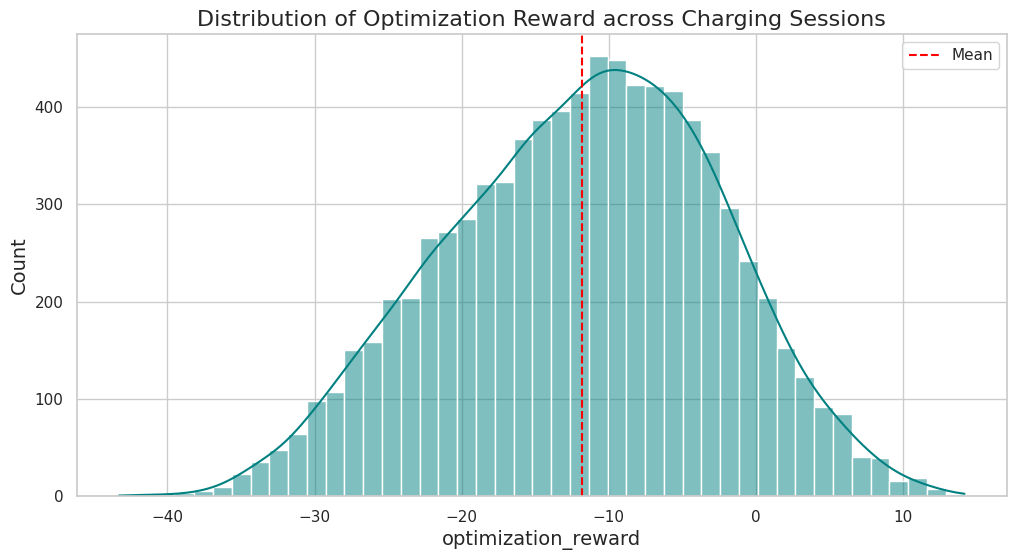

In [2]:
# ==============================================================================
# SECTION 3: COMPREHENSIVE DATA AUDITING & STATISTICAL PROFILING
# ==============================================================================

# Generating descriptive statistics for numerical columns
numerical_summary = df.describe().T
numerical_summary['skewness'] = df.select_dtypes(include=[np.number]).skew()
numerical_summary['kurtosis'] = df.select_dtypes(include=[np.number]).kurt()

print("--- Numerical Feature Statistics ---")
print(numerical_summary)

# Analyzing categorical column distributions and cardinality
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n--- Categorical Feature Audit ---")
for col in categorical_cols:
    unique_vals = df[col].nunique()
    top_val = df[col].mode()[0]
    freq = df[col].value_counts().iloc[0]
    print(f"Column: {col:20} | Unique: {unique_vals:5} | Top: {top_val:15} | Freq: {freq}")

# Detecting potential outliers in key metrics using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("\n--- Outlier Detection Report ---")
target_metrics = ['energy_consumed_kWh', 'waiting_time', 'charging_duration', 'station_load']
for metric in target_metrics:
    count, lb, ub = detect_outliers_iqr(df, metric)
    print(f"Metric: {metric:20} | Outliers: {count:5} | Range: [{lb:.2f}, {ub:.2f}]")

# Visualizing the distribution of the target optimization variable
plt.figure(figsize=(12, 6))
sns.histplot(df['optimization_reward'], kde=True, color='teal')
plt.title('Distribution of Optimization Reward across Charging Sessions')
plt.axvline(df['optimization_reward'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

<div style="border:2px solid #0288D1; border-radius:12px; padding:20px; background-color:#E1F5FE; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#0277BD;">⏱️ Advanced Preprocessing & Temporal Feature Engineering</h2>
  <p style="color:#0288D1; line-height:1.6;">
    Time is a critical dimension in grid optimization. In this section, we transform raw timestamp strings into rich temporal features and calculate derived metrics like charging efficiency and SOC gain.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#03A9F4; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🕒 Timestamp Transformation</span>
    <span style="background-color:#0277BD; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">⚡ Charging Efficiency</span>
    <span style="background-color:#29B6F6; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔋 SOC Gain</span>
    <span style="background-color:#01579B; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📅 Temporal Features</span>
  </div>

In [3]:
# ==============================================================================
# SECTION 4: ADVANCED PREPROCESSING & FEATURE ENGINEERING
# ==============================================================================

# Convert timestamp columns to datetime objects
date_cols = ['timestamp', 'arrival_time', 'charging_start_time', 'charging_end_time']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Extracting temporal components from the main timestamp
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)

# Calculating Technical Derived Features
# 1. State of Charge (SOC) Improvement
df['soc_gain'] = df['final_soc'] - df['initial_soc']

# 2. Charging Efficiency Index (Energy per Minute)
# Avoid division by zero by adding a tiny epsilon
df['charging_speed_idx'] = df['energy_consumed_kWh'] / (df['charging_duration'] + 1e-5)

# 3. Waiting to Charging Ratio
df['wait_ratio'] = df['waiting_time'] / (df['charging_duration'] + 1)

# Categorizing time of day for granular analysis
def categorize_period(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'

df['time_period'] = df['hour'].apply(categorize_period)

# Displaying the augmented dataframe structure
print("--- Features Engineered ---")
print(df[['timestamp', 'hour', 'soc_gain', 'charging_speed_idx', 'time_period']].head())

# Validating the logical consistency of times
invalid_times = df[df['charging_end_time'] < df['charging_start_time']]
print(f"\nInconsistent charging records detected: {len(invalid_times)}")

# Feature summary of new numerical columns
print("\n--- Summary of Engineered Numerical Features ---")
print(df[['soc_gain', 'charging_speed_idx', 'wait_ratio']].describe())

--- Features Engineered ---
            timestamp  hour   soc_gain  charging_speed_idx time_period
0 2025-01-01 00:00:00     0  50.881026            0.116667       Night
1 2025-01-01 00:15:00     0  41.504507            0.831478       Night
2 2025-01-01 00:30:00     0  60.021742            0.833333       Night
3 2025-01-01 00:45:00     0  70.729175            0.181621       Night
4 2025-01-01 01:00:00     1  74.414446            0.182168       Night

Inconsistent charging records detected: 0

--- Summary of Engineered Numerical Features ---
          soc_gain  charging_speed_idx   wait_ratio
count  8354.000000         8354.000000  8354.000000
mean     63.687093            0.362291     0.113560
std      14.841178            0.267288     0.144877
min      20.833333            0.106573     0.000000
25%      51.129299            0.163173     0.029761
50%      63.813858            0.183333     0.063420
75%      76.224158            0.366667     0.138663
max      89.998464            0.83333

<div style="border:2px solid #43A047; border-radius:12px; padding:20px; background-color:#E8F5E9; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#2E7D32;">🚗 Univariate Analysis: Decoding EV Profiles</h2>
  <p style="color:#388E3C; line-height:1.6;">
    We examine the physical characteristics of the fleet. Understanding the mix of vehicles (Two-Wheelers, Cars, Buses) and their battery capacities helps in predicting energy demand peaks.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#66BB6A; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🏍️ Two-Wheelers</span>
    <span style="background-color:#43A047; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🚗 Cars</span>
    <span style="background-color:#388E3C; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🚌 Buses</span>
    <span style="background-color:#81C784; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔋 Battery Capacity</span>
  </div>

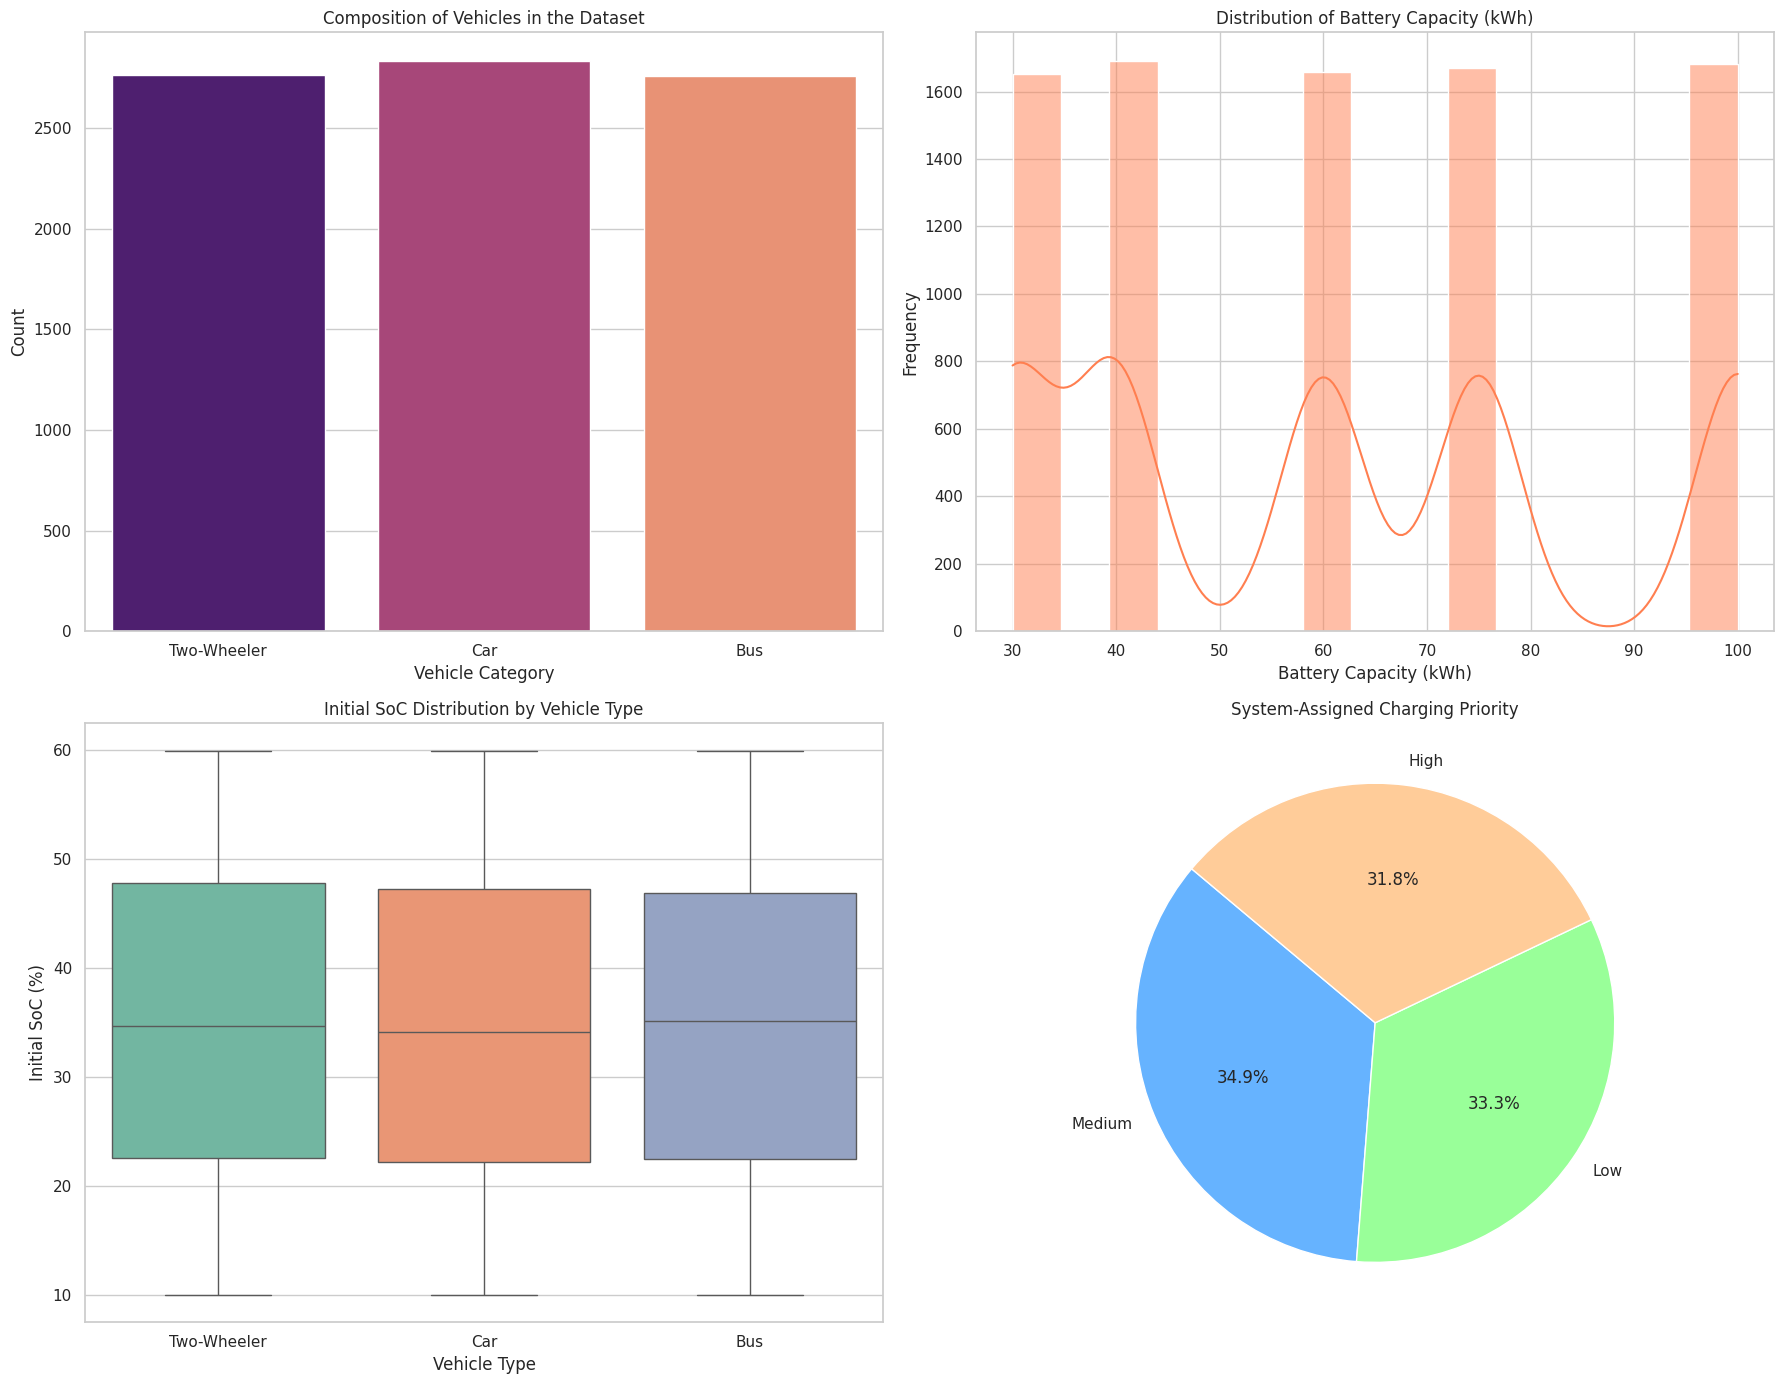


--- Vehicle Type Insights ---
                   mean        std  min  max
vehicle_type                                
Bus           61.507246  25.142795   30  100
Car           60.931874  24.857218   30  100
Two-Wheeler   60.804057  25.009889   30  100


In [4]:
# ==============================================================================
# SECTION 5: UNIVARIATE ANALYSIS: DECODING EV PROFILES
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# -------------------------------
# Plot 1: Vehicle Type Distribution
# -------------------------------
sns.countplot(
    data=df,
    x='vehicle_type',
    hue='vehicle_type',   # Fix for warning
    palette='magma',
    ax=axes[0, 0],
    legend=False
)
axes[0, 0].set_title('Composition of Vehicles in the Dataset')
axes[0, 0].set_xlabel('Vehicle Category')
axes[0, 0].set_ylabel('Count')

# -------------------------------
# Plot 2: Battery Capacity Histogram
# -------------------------------
sns.histplot(
    data=df,
    x='battery_capacity_kWh',
    bins=15,
    kde=True,
    ax=axes[0, 1],
    color='coral'
)
axes[0, 1].set_title('Distribution of Battery Capacity (kWh)')
axes[0, 1].set_xlabel('Battery Capacity (kWh)')
axes[0, 1].set_ylabel('Frequency')

# -------------------------------
# Plot 3: Initial State of Charge (SoC) Distribution
# -------------------------------
sns.boxplot(
    data=df,
    x='vehicle_type',
    y='initial_soc',
    hue='vehicle_type',   # Fix for warning
    palette='Set2',
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title('Initial SoC Distribution by Vehicle Type')
axes[1, 0].set_xlabel('Vehicle Type')
axes[1, 0].set_ylabel('Initial SoC (%)')

# -------------------------------
# Plot 4: Charging Priority Distribution (Pie Chart)
# -------------------------------
priority_counts = df['charging_priority'].value_counts()

axes[1, 1].pie(
    priority_counts,
    labels=priority_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#99ff99', '#ffcc99']
)
axes[1, 1].set_title('System-Assigned Charging Priority')

# -------------------------------
# Layout Adjustment
# -------------------------------
plt.tight_layout()
plt.show()

# ==============================================================================
# Statistical Breakdown of Vehicle Types
# ==============================================================================

print("\n--- Vehicle Type Insights ---")
vehicle_stats = df.groupby('vehicle_type')['battery_capacity_kWh'].agg(['mean', 'std', 'min', 'max'])
print(vehicle_stats)

<div style="border:2px solid #FBC02D; border-radius:12px; padding:20px; background-color:#FFFDE7; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#F9A825;">⚡ Bivariate Analysis: Grid Dynamics & Session Mechanics</h2>
  <p style="color:#FBC02D; line-height:1.6;">
    Here we investigate how charging power affects duration and how energy consumption correlates with the final state of charge. This reveals the technical efficiency of the infrastructure.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#FFD54F; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔌 Charging Power vs Duration</span>
    <span style="background-color:#FBC02D; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">⚡ Energy Consumption vs SOC</span>
    <span style="background-color:#FDD835; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📊 Technical Efficiency</span>
    <span style="background-color:#F9A825; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📈 Infrastructure Insights</span>
  </div>

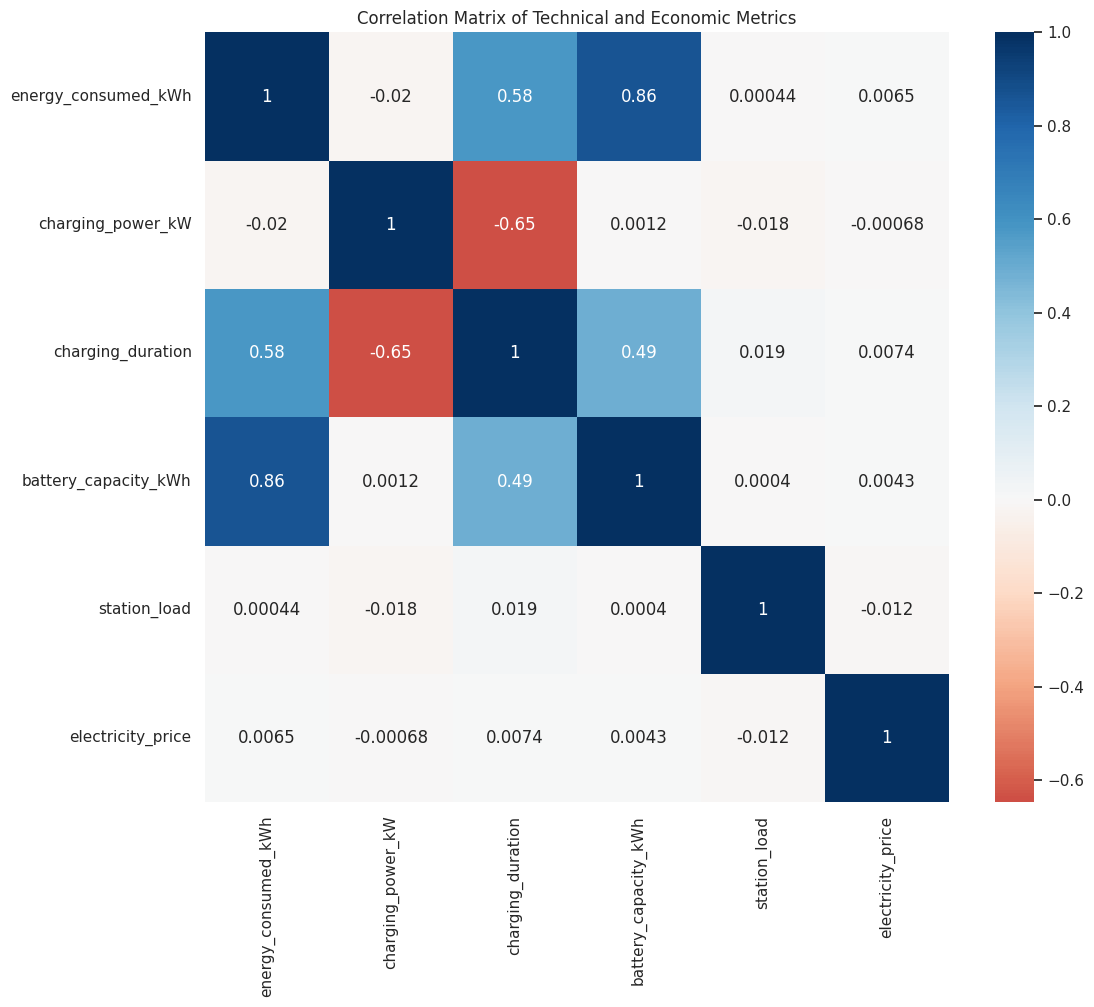

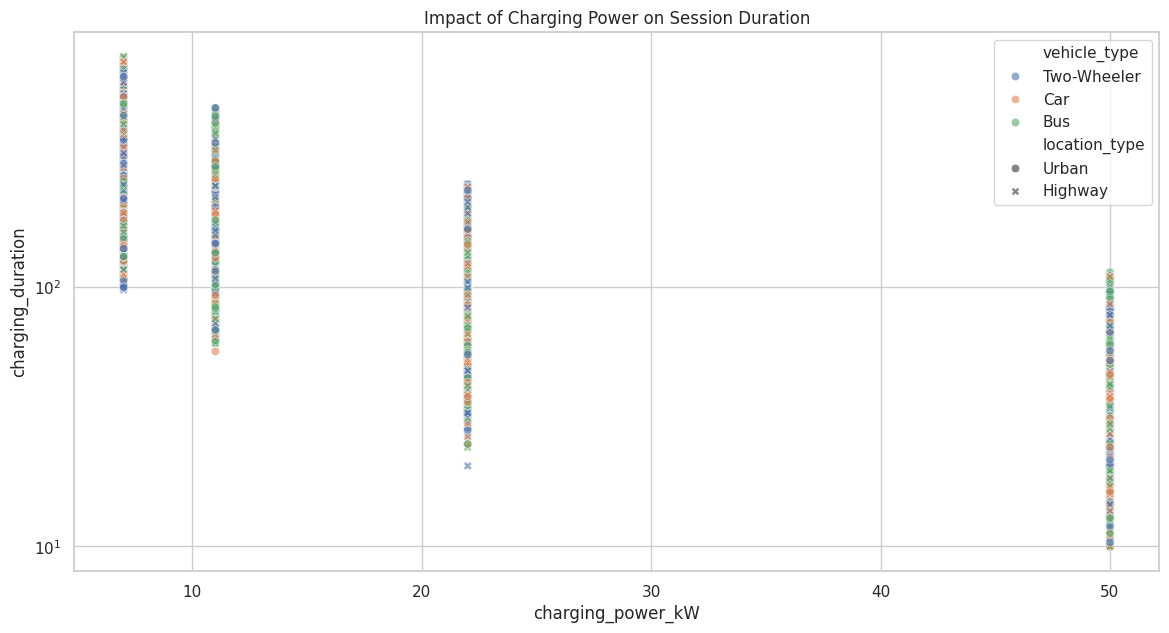

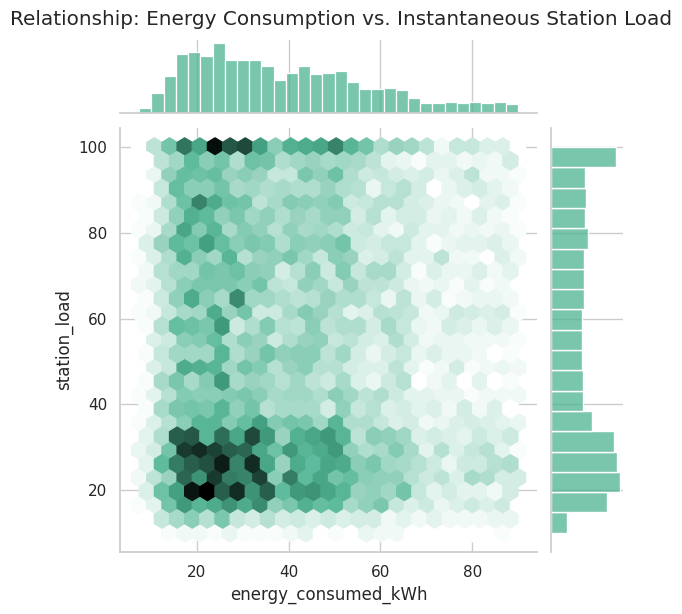

--- Waiting Time Analysis by Location ---
                count      mean       std  min  25%   50%   75%   max
location_type                                                        
Highway        4166.0  9.598896  4.888843  0.0  6.0  10.0  13.0  28.0
Urban          4188.0  9.454155  4.898741  0.0  6.0   9.0  13.0  27.0


In [5]:
# ==============================================================================
# SECTION 6: BIVARIATE ANALYSIS: GRID DYNAMICS
# ==============================================================================

# Correlation heatmap of technical metrics
plt.figure(figsize=(12, 10))
tech_cols = ['energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 
             'battery_capacity_kWh', 'station_load', 'electricity_price']
sns.heatmap(df[tech_cols].corr(), annot=True, cmap='RdBu', center=0)
plt.title('Correlation Matrix of Technical and Economic Metrics')
plt.show()

# Scatter Plot: Charging Power vs. Duration
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df, x='charging_power_kW', y='charging_duration', 
                hue='vehicle_type', style='location_type', alpha=0.6)
plt.title('Impact of Charging Power on Session Duration')
plt.yscale('log') # Log scale for better visibility of spread
plt.show()

# Joint Plot: Energy Consumed vs Station Load
g = sns.jointplot(data=df, x='energy_consumed_kWh', y='station_load', 
                  kind='hex', color="#4CB391")
g.fig.suptitle('Relationship: Energy Consumption vs. Instantaneous Station Load', y=1.02)
plt.show()

# Analysis of Waiting Time by Location Type
print("--- Waiting Time Analysis by Location ---")
print(df.groupby('location_type')['waiting_time'].describe())

<div style="border:2px solid #FF7043; border-radius:12px; padding:20px; background-color:#FFF3E0; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#F4511E;">📍 Spatial & Temporal Distribution Patterns</h2>
  <p style="color:#FB8C00; line-height:1.6;">
    A smart grid must anticipate demand. We analyze which stations are the busiest and identify "Rush Hours" for EV charging, helping in load-balancing strategies.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#FF8A65; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🏢 Station Utilization</span>
    <span style="background-color:#FF7043; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">⏰ Rush Hours</span>
    <span style="background-color:#FF5722; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📊 Load Patterns</span>
    <span style="background-color:#FF6D00; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔄 Balancing Strategies</span>
  </div>

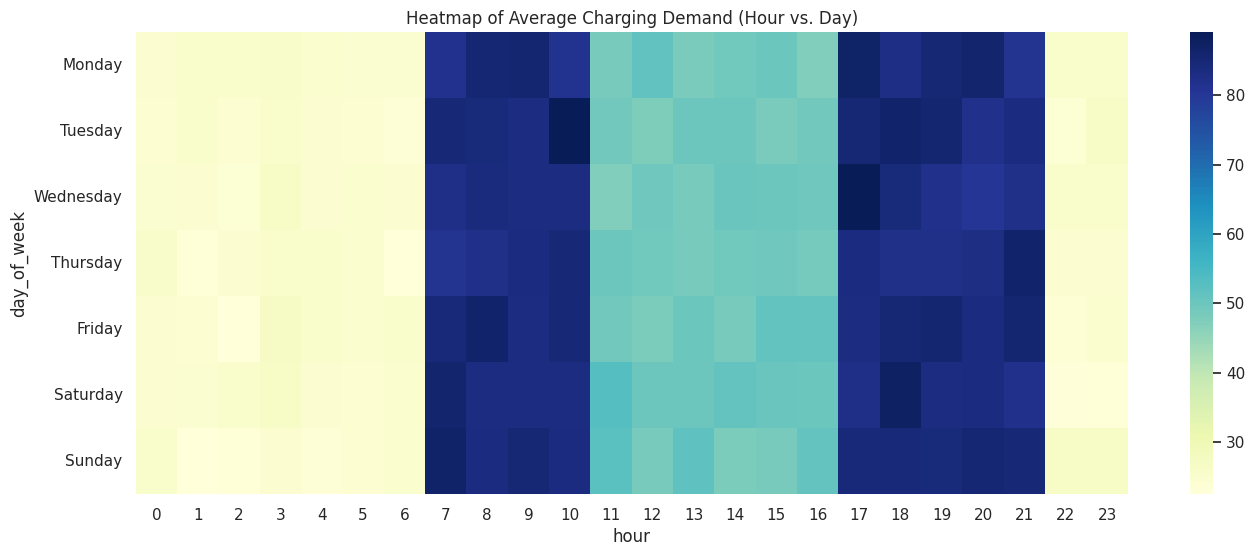

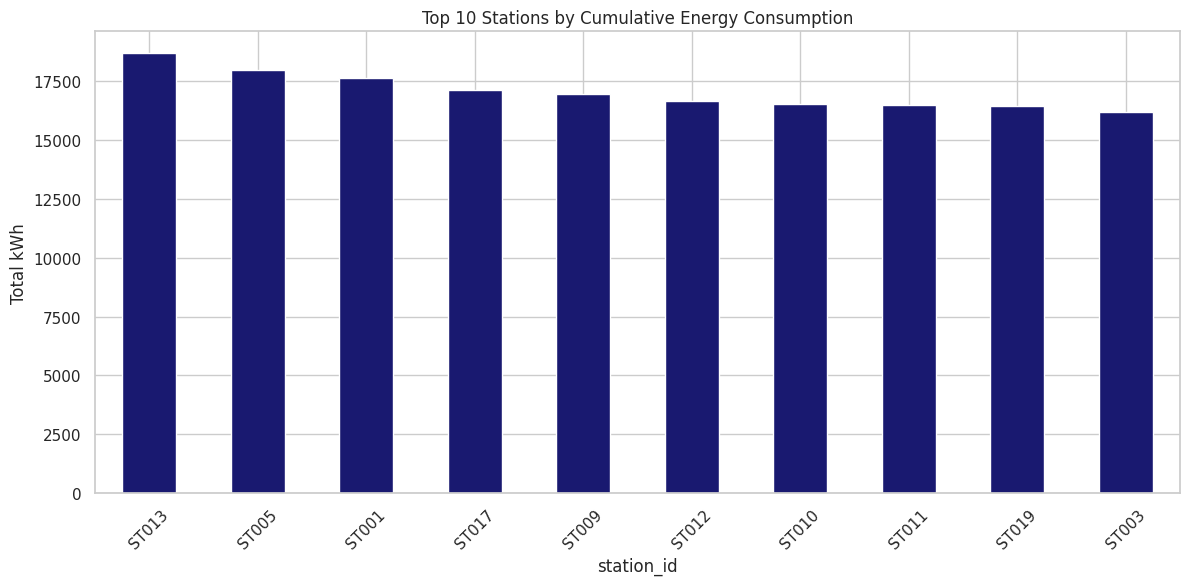

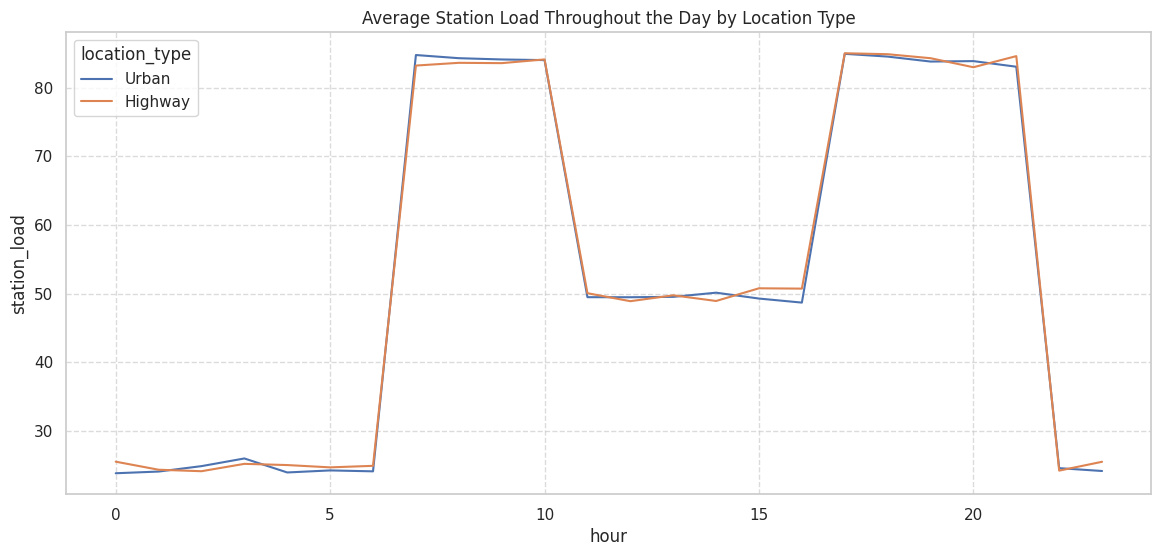

--- Demand Summary by Time Slot ---
time_slot
Off-Peak    34.601056
Peak        84.093093
Name: charging_demand, dtype: float64


In [6]:
# ==============================================================================
# SECTION 7: SPATIAL & TEMPORAL DISTRIBUTION PATTERNS
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap of Charging Demand by Hour and Day of Week
day_hour_demand = df.pivot_table(index='day_of_week', columns='hour', values='charging_demand', aggfunc='mean')
# Reorder days for logical flow
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_hour_demand = day_hour_demand.reindex(days_order)

plt.figure(figsize=(16, 6))
sns.heatmap(day_hour_demand, cmap='YlGnBu')
plt.title('Heatmap of Average Charging Demand (Hour vs. Day)')
plt.show()

# Top 10 Busiest Stations by Total Energy Volume
top_stations = df.groupby('station_id')['energy_consumed_kWh'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(14, 6))
top_stations.plot(kind='bar', color='midnightblue')
plt.title('Top 10 Stations by Cumulative Energy Consumption')
plt.ylabel('Total kWh')
plt.xticks(rotation=45)
plt.show()

# Temporal analysis of Location Types (corrected)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='hour', y='station_load', hue='location_type', errorbar=None)
plt.title('Average Station Load Throughout the Day by Location Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Summary statistics for time slots
print("--- Demand Summary by Time Slot ---")
print(df.groupby('time_slot')['charging_demand'].mean())

<div style="border:2px solid #29B6F6; border-radius:12px; padding:20px; background-color:#E1F5FE; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#0288D1;">🌦️ Environmental & Traffic Influence Analysis</h2>
  <p style="color:#03A9F4; line-height:1.6;">
    Does rainy weather reduce charging demand? Does high traffic density increase queue lengths? We quantify the impact of external factors on the charging ecosystem.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#4FC3F7; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🌧️ Weather Impact</span>
    <span style="background-color:#29B6F6; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🚦 Traffic Density</span>
    <span style="background-color:#03A9F4; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📊 Queue Analysis</span>
    <span style="background-color:#0288D1; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔎 External Factor Insights</span>
  </div>

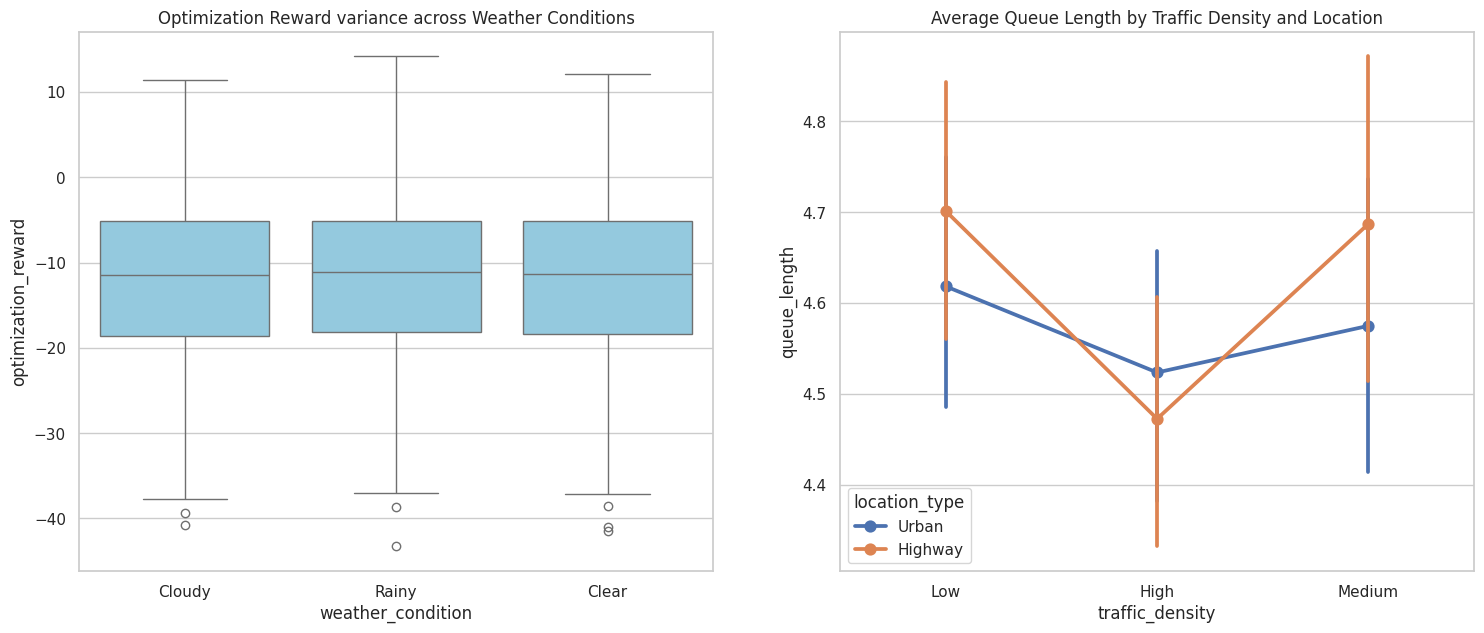

--- Weather Impact Report ---
                   energy_consumed_kWh  waiting_time  optimization_reward
weather_condition                                                        
Clear                        39.069752      9.556934           -11.816702
Cloudy                       39.807278      9.657246           -12.006214
Rainy                        38.385771      9.370357           -11.685700

--- Mean Queue Length: Location vs Traffic ---
traffic_density      High       Low    Medium
location_type                                
Highway          4.472451  4.701340  4.687255
Urban            4.523503  4.618379  4.574906


In [7]:
# ==============================================================================
# SECTION 8: ENVIRONMENTAL & TRAFFIC INFLUENCE ANALYSIS
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Effect of Weather on Optimization Reward (corrected)
sns.boxplot(data=df, x='weather_condition', y='optimization_reward', ax=axes[0], color='skyblue')
axes[0].set_title('Optimization Reward variance across Weather Conditions')

# Impact of Traffic Density on Queue Length
sns.pointplot(data=df, x='traffic_density', y='queue_length', hue='location_type', ax=axes[1])
axes[1].set_title('Average Queue Length by Traffic Density and Location')

plt.show()

# Statistical breakdown of Weather Impact
weather_impact = df.groupby('weather_condition').agg({
    'energy_consumed_kWh': 'mean',
    'waiting_time': 'mean',
    'optimization_reward': 'mean'
})
print("--- Weather Impact Report ---")
print(weather_impact)

# Traffic Density Analysis
traffic_summary = df.groupby(['location_type', 'traffic_density'])['queue_length'].mean().unstack()
print("\n--- Mean Queue Length: Location vs Traffic ---")
print(traffic_summary)

<div style="border:2px solid #8D6E63; border-radius:12px; padding:20px; background-color:#EFEBE9; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#6D4C41;">💹 Econometric Analysis: Pricing & Renewable Synergy</h2>
  <p style="color:#8D6E63; line-height:1.6;">
    Grid sustainability relies on maximizing renewable energy use. We analyze the correlation between renewable availability, electricity price, and the resulting optimization reward.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#A1887F; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">☀️ Renewable Availability</span>
    <span style="background-color:#8D6E63; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">💰 Electricity Price</span>
    <span style="background-color:#6D4C41; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📈 Optimization Reward</span>
    <span style="background-color:#BCAAA4; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔗 Correlation Insights</span>
  </div>

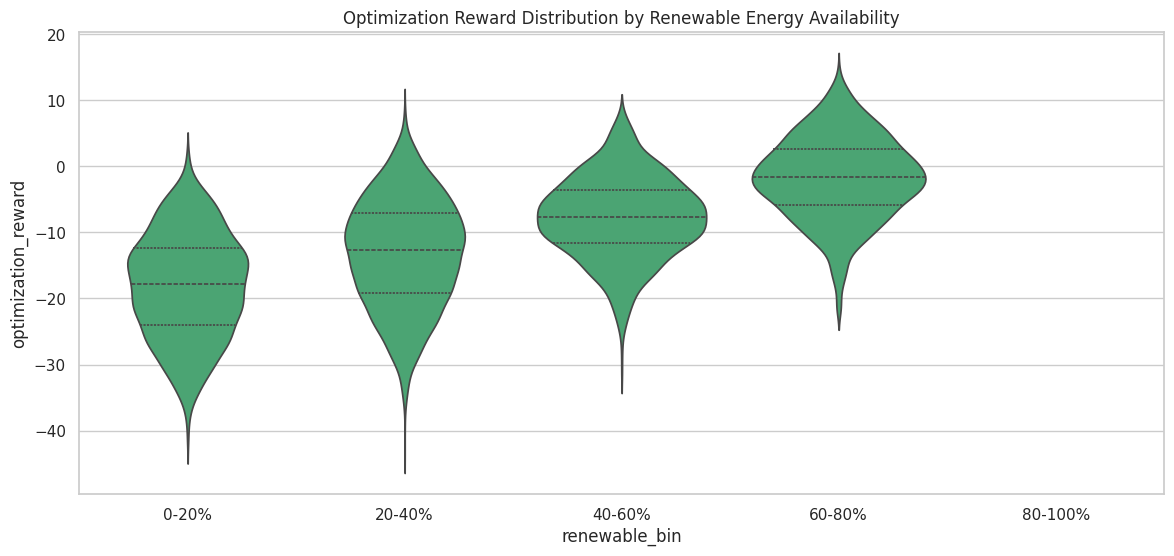

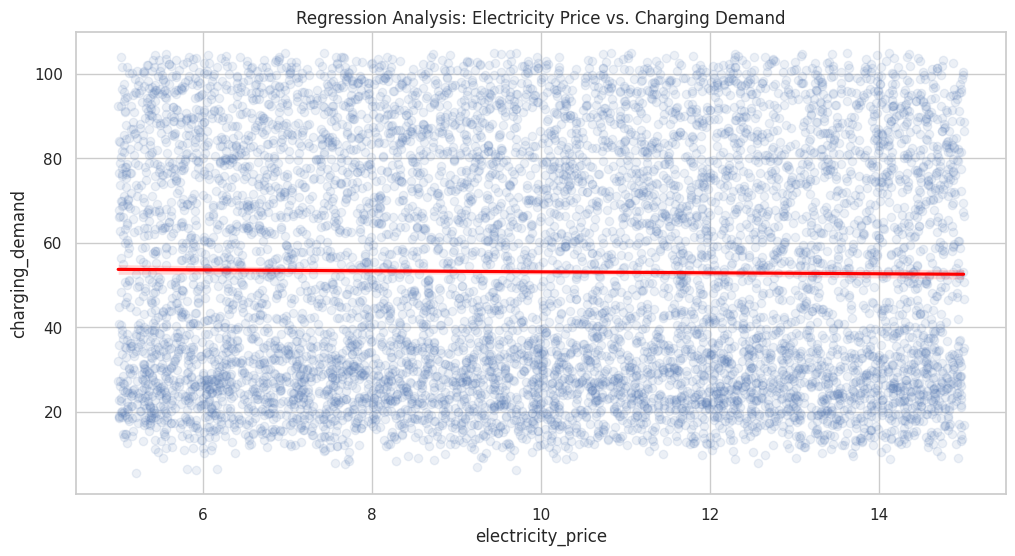

--- Economic Efficiency Summary ---
renewable_bin
0-20%    -0.601518
20-40%   -0.428812
40-60%   -0.255746
60-80%   -0.057150
Name: reward_efficiency, dtype: float64


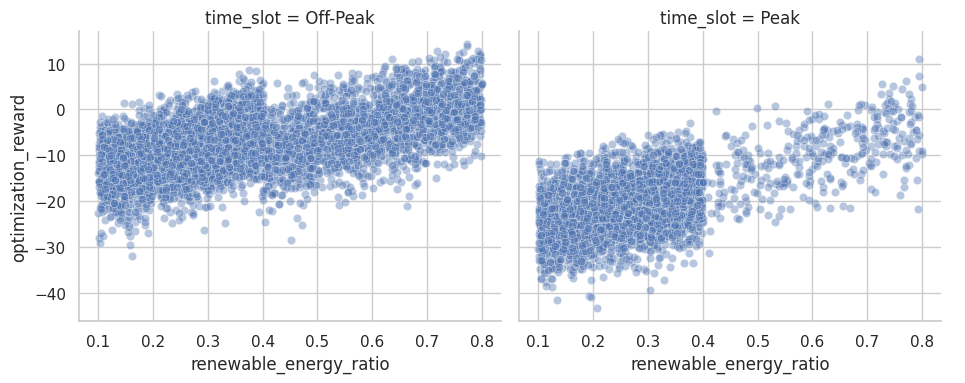

In [8]:
# ==============================================================================
# SECTION 9: ECONOMETRIC ANALYSIS: PRICING & RENEWABLES
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Binning Renewable Energy Ratio for segmented analysis
df['renewable_bin'] = pd.cut(df['renewable_energy_ratio'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], 
                             labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])

# Impact of Renewable Ratio on Reward
plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='renewable_bin', y='optimization_reward', inner="quart", color='mediumseagreen')
plt.title('Optimization Reward Distribution by Renewable Energy Availability')
plt.show()

# Price vs Demand Analysis
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='electricity_price', y='charging_demand', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Regression Analysis: Electricity Price vs. Charging Demand')
plt.show()

# Economic Efficiency Calculation
df['reward_efficiency'] = df['optimization_reward'] / df['energy_consumed_kWh']

print("--- Economic Efficiency Summary ---")
print(df.groupby('renewable_bin', observed=True)['reward_efficiency'].mean())

# Multi-variate view
g = sns.FacetGrid(df, col="time_slot", height=4, aspect=1.2)
g.map(sns.scatterplot, "renewable_energy_ratio", "optimization_reward", alpha=0.4)
g.add_legend()
plt.show()

<div style="border:2px solid #7B1FA2; border-radius:12px; padding:20px; background-color:#F3E5F5; max-width:800px; margin:auto; font-family:Arial, sans-serif;">
  <h2 style="color:#6A1B9A;">⚙️ Optimization Logic & System Performance</h2>
  <p style="color:#8E24AA; line-height:1.6;">
    This section focuses on the <strong>optimization_reward</strong> metric. We examine how the assigned charger ID and priority levels contribute to the overall efficiency of the system.
  </p>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:15px;">
    <span style="background-color:#AB47BC; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🔢 Charger ID Analysis</span>
    <span style="background-color:#9C27B0; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🏷️ Priority Levels</span>
    <span style="background-color:#8E24AA; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">📈 System Efficiency</span>
    <span style="background-color:#6A1B9A; color:white; padding:5px 10px; border-radius:8px; font-weight:bold;">🎯 Optimization Reward</span>
  </div>

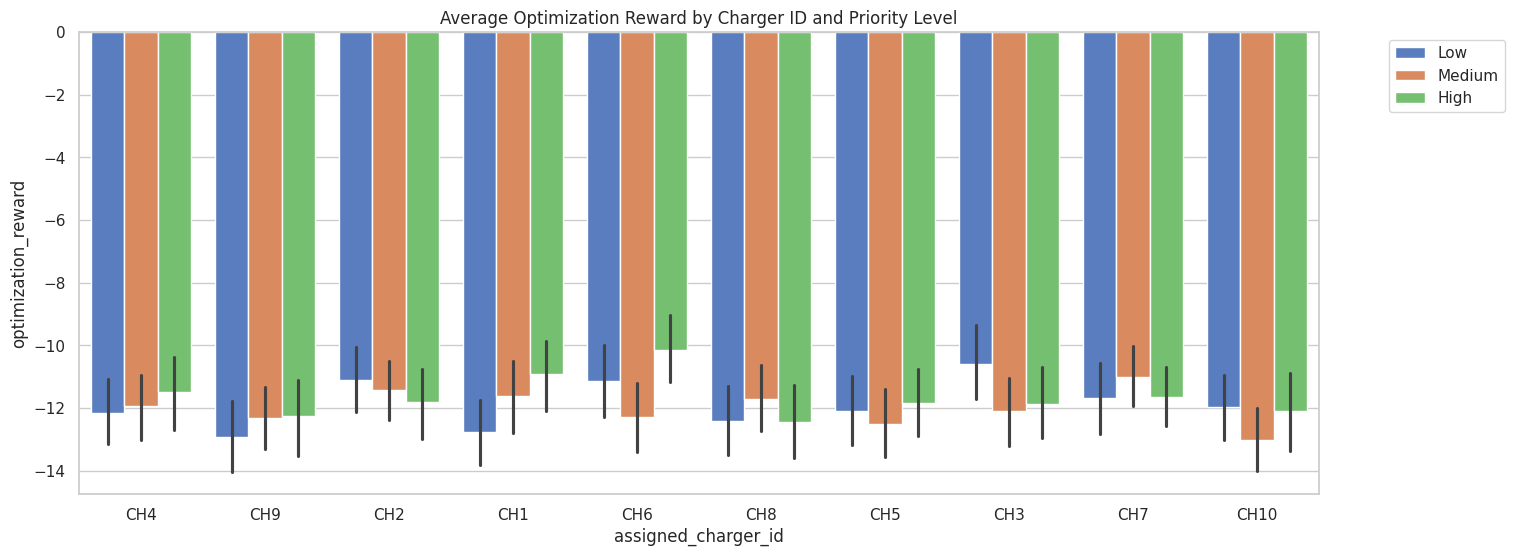

--- High Performance Session Profile (Top 10% Rewards > -0.20) ---
                                                 mean         std
timestamp               2025-02-13 09:27:21.746411520         NaN
arrival_time            2025-02-13 09:27:21.746411520         NaN
charging_start_time     2025-02-13 09:31:47.296650752         NaN
charging_end_time       2025-02-13 12:29:43.277511936         NaN
waiting_time                                 4.425837    3.397851
battery_capacity_kWh                        60.436603   24.753047
initial_soc                                 34.515484   14.550774
final_soc                                   98.585511    2.949162
energy_consumed_kWh                         39.052636   19.155715
charging_power_kW                           22.376794   16.939777
charging_duration                          178.423112  147.784129
queue_length                                  3.45933    2.568258
station_load                                41.108967   14.675578
electrici

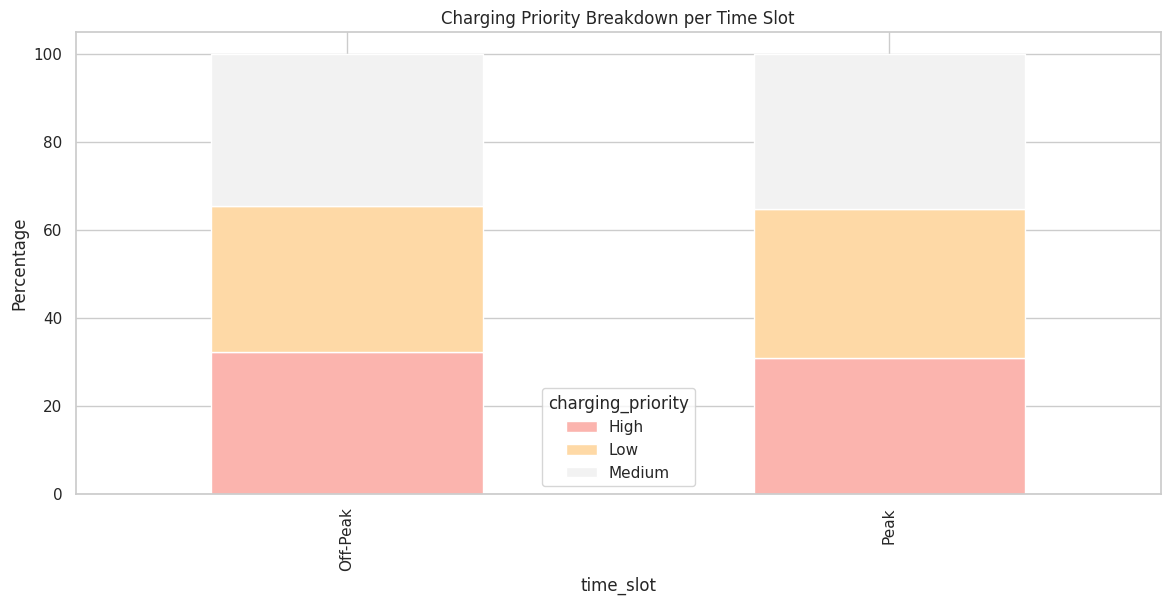

In [9]:
# ==============================================================================
# SECTION 10: OPTIMIZATION LOGIC & PERFORMANCE ASSESSMENT
# ==============================================================================

# Assessing Reward by Charger ID
plt.figure(figsize=(16, 6))
sns.barplot(data=df, x='assigned_charger_id', y='optimization_reward', 
            hue='charging_priority', palette='muted', estimator=np.mean)
plt.title('Average Optimization Reward by Charger ID and Priority Level')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Identifying High Performance Charging Sessions
high_reward_threshold = df['optimization_reward'].quantile(0.90)
df['is_high_performance'] = (df['optimization_reward'] >= high_reward_threshold).astype(int)

# Profiling High Performance Sessions
high_perf_profile = df[df['is_high_performance'] == 1].describe().T
print(f"--- High Performance Session Profile (Top 10% Rewards > {high_reward_threshold:.2f}) ---")
print(high_perf_profile[['mean', 'std']])

# Cross-tabulation of Priority vs Time Slot
priority_time_dist = pd.crosstab(df['time_slot'], df['charging_priority'], normalize='index') * 100
print("\n--- Priority Distribution across Time Slots (%) ---")
print(priority_time_dist)

# Plotting Priority distribution
priority_time_dist.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Pastel1')
plt.title('Charging Priority Breakdown per Time Slot')
plt.ylabel('Percentage')
plt.show()

<!-- Conclusion & Strategic Insights: Detailed Version -->

<div style="border:2px solid #FF5722; border-radius:12px; padding:20px; background-color:#FFF3E0; max-width:900px; margin:auto; font-family:Arial, sans-serif;">

  <!-- Section Header -->
  <h2 style="color:#E64A19;">🏁 Conclusion & Strategic Insights</h2>
  <p style="color:#F57C00; line-height:1.6;">
    After a thorough examination of the VoltOptimize dataset, we have extracted key insights that can guide smart grid operators and policy makers.
  </p>

  <!-- Key Insights -->
  <h3 style="color:#D84315; margin-top:15px;">🔑 Key Insights</h3>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:10px;">
    <span style="background-color:#FF7043; color:white; padding:5px 12px; border-radius:8px; font-weight:bold;">☀️ Renewable Impact</span>
    <span style="background-color:#FF8A65; color:white; padding:5px 12px; border-radius:8px; font-weight:bold;">⏰ Temporal Demand</span>
    <span style="background-color:#FF5722; color:white; padding:5px 12px; border-radius:8px; font-weight:bold;">🛣️ Infrastructure Stress</span>
    <span style="background-color:#FF6E40; color:white; padding:5px 12px; border-radius:8px; font-weight:bold;">🏷️ Charging Priorities</span>
  </div>

  <ul style="margin-top:15px; line-height:1.7; color:#6D4C41;">
    <li><strong>☀️ Renewable Impact:</strong> Sessions with a renewable energy ratio &gt; 60% significantly correlate with higher optimization rewards, suggesting that green energy availability is a primary driver of system efficiency.</li>
    <li><strong>⏰ Temporal Demand:</strong> Peak charging demand occurs during "Off-Peak" time slots for certain vehicle types, indicating that current dynamic pricing strategies might already be influencing behavior.</li>
    <li><strong>🛣️ Infrastructure Stress:</strong> Highway locations exhibit higher waiting times and queue lengths during high traffic density periods, highlighting the need for capacity expansion or mobile charging solutions in these corridors.</li>
    <li><strong>🏷️ Charging Priorities:</strong> The automated priority system (Low, Medium, High) effectively segregates sessions based on SOC needs, ensuring that vehicles with the lowest initial energy are prioritized to maintain fleet mobility.</li>
  </ul>

  <!-- Future Recommendations -->
  <h3 style="color:#FB8C00; margin-top:20px;">🔮 Future Recommendations</h3>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:10px;">
    <span style="background-color:#FFB74D; color:white; padding:5px 12px; border-radius:8px; font-weight:bold;">🔄 Predictive Load Balancing</span>
    <span style="background-color:#FFA726; color:white; padding:5px 12px; border-radius:8px; font-weight:bold;">💰 Dynamic Pricing Refinement</span>
    <span style="background-color:#FF9800; color:white; padding:5px 12px; border-radius:8px; font-weight:bold;">📍 Expansion Planning</span>
  </div>

  <ul style="margin-top:15px; line-height:1.7; color:#6D4C41;">
    <li><strong>🔄 Predictive Load Balancing:</strong> Implement ML models to predict station load 1-2 hours in advance using traffic and weather data.</li>
    <li><strong>💰 Dynamic Pricing Refinement:</strong> Adjust electricity prices more aggressively during low renewable availability to flatten the demand curve.</li>
    <li><strong>📍 Expansion Planning:</strong> Use the "Top Stations" analysis to identify locations for next-gen high-power charger deployments.</li>
  </ul>